In [1]:
import ee
import geopandas as gpd
import folium
import os
import subprocess
from shapely.geometry import mapping, MultiPolygon
from google.colab import drive
drive.mount('/content/drive')
ee.Authenticate()
# Initialize Earth Engine
ee.Initialize(project="ndvi-460519")
#ndvi-460519
#agrisat-463314

Mounted at /content/drive


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ⭐ Visualisation ▶ 2 Céllules suivantes

In [4]:
# Load your shapefile
shapefile_path = f"/content/drive/MyDrive/Agriculture 2.0/AOI Benyagrine 2/AOIBenyagrine2.shp"
gdf = gpd.read_file(shapefile_path)
gdf = gdf.to_crs(epsg="4326")
geom = gdf.geometry.union_all()
if geom.geom_type == 'Polygon':
    geom = MultiPolygon([geom])
aoi_geom = mapping(geom)
aoi = ee.Geometry(aoi_geom)
#####################################################
collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')\
                  .filterBounds(aoi)\
                  .filterDate('2025-08-01', '2025-09-13')\
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',(20)))
tiles = collection.toList(collection.size())
#####################################################
n_images = collection.size().getInfo()
images = collection.toList(n_images)
dates = []
for i in range(n_images):
    image = ee.Image(images.get(i))
    timestamp = image.date().format('YYYY-MM-dd').getInfo()
    dates.append(timestamp)
print("Acquisition dates:", dates)
#####################################################

Acquisition dates: ['2025-08-03', '2025-08-08', '2025-08-13', '2025-08-18', '2025-08-20', '2025-08-28', '2025-09-02', '2025-09-07', '2025-09-12']


In [5]:
# On va stocker toutes les stats
stats_dict = {}

for d in range(len(dates)):
    img = ee.Image(tiles.get(d))

    # Sélections de bandes
    red = img.select('B4')
    green = img.select('B3')
    blue = img.select('B2')
    nir = img.select('B8')
    red_edge = img.select('B5')
    r531 = img.select('B5')
    r570 = img.select('B6')
    swir = img.select('B11')

    # Indices standards
    ndvi = nir.subtract(red).divide(nir.add(red)).rename('NDVI').clip(aoi)
    pri = r531.subtract(r570).divide(r531.add(r570)).rename('PRI').clip(aoi)
    ndre = nir.subtract(red_edge).divide(nir.add(red_edge)).rename('NDRE').clip(aoi)
    gci = (nir.divide(green)).subtract(1).rename('GCI').clip(aoi)
    mndwi = green.subtract(swir).divide(green.add(swir)).rename('MNDWI').clip(aoi)

    eps = ee.Number(1e-6)
    ratio = nir.subtract(red).divide(nir.add(red).add(eps))
    mvi = ratio.add(0.5).sqrt().rename('MVI').clip(aoi)

    ndmi = nir.subtract(swir).divide(nir.add(swir)).rename('NDMI').clip(aoi)
    msi = swir.divide(nir).rename('MSI').clip(aoi)

    ls = [ndvi, pri, ndre, gci, mndwi, mvi, ndmi, msi]
    ls_str = ["NDVI", "PRI", "NDRE", "GCI", "MNDWI", "MVI", "NDMI", "MSI"]

    dir_dw = "test_plots"

    for ind, ind_st in zip(ls, ls_str):
        # 🔹 Export GeoTIFF (comme avant)
        ee.batch.Export.image.toDrive(
            image=ind,
            description=f'{ind_st}_{dates[d]}',
            folder=dir_dw,
            scale=10,
            maxPixels=1e13,
            fileFormat='GeoTIFF'
        ).start()

        # 🔹 Calcul des stats avec ee.Reducer
        reducer = ee.Reducer.mean() \
            .combine(ee.Reducer.median(), '', True) \
            .combine(ee.Reducer.percentile([10, 90]), '', True) \
            .combine(ee.Reducer.stdDev(), '', True)

        stats = ind.reduceRegion(
            reducer=reducer,
            geometry=aoi,
            scale=10,
            maxPixels=1e13
        ).getInfo()

        # Sauvegarder dans dict
        stats_dict.setdefault(ind_st, []).append({
            "Date": dates[d],
            "Mean": stats.get(f"{ind_st}_mean"),
            "Median": stats.get(f"{ind_st}_median"),
            "P10": stats.get(f"{ind_st}_p10"),
            "P90": stats.get(f"{ind_st}_p90"),
            "Std": stats.get(f"{ind_st}_stdDev")
        })

# Sauvegarde dans un CSV
import pandas as pd
df_stats = []
for ind, values in stats_dict.items():
    for v in values:
        row = {"Index": ind}
        row.update(v)
        df_stats.append(row)

df_stats = pd.DataFrame(df_stats)
csv_path = "/content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/statistics_summary.csv"
df_stats.to_csv(csv_path, index=False)
print("📊 Stats sauvegardées ->", csv_path)


📊 Stats sauvegardées -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/statistics_summary.csv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 85.6 MB/s eta 0:00:00


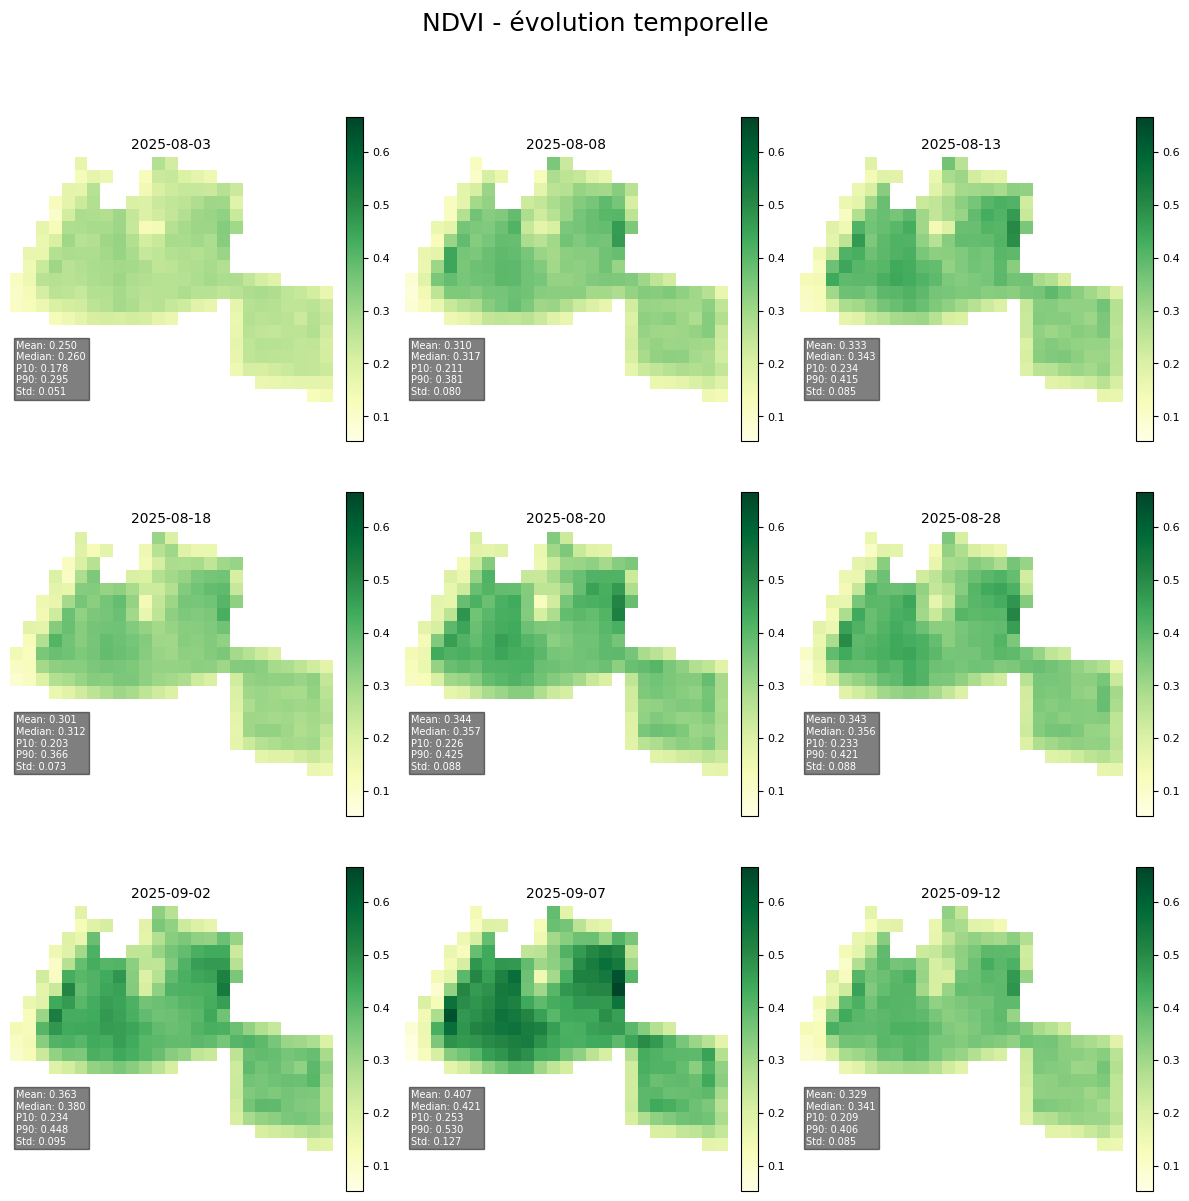

✅ NDVI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/NDVI_all_dates.png


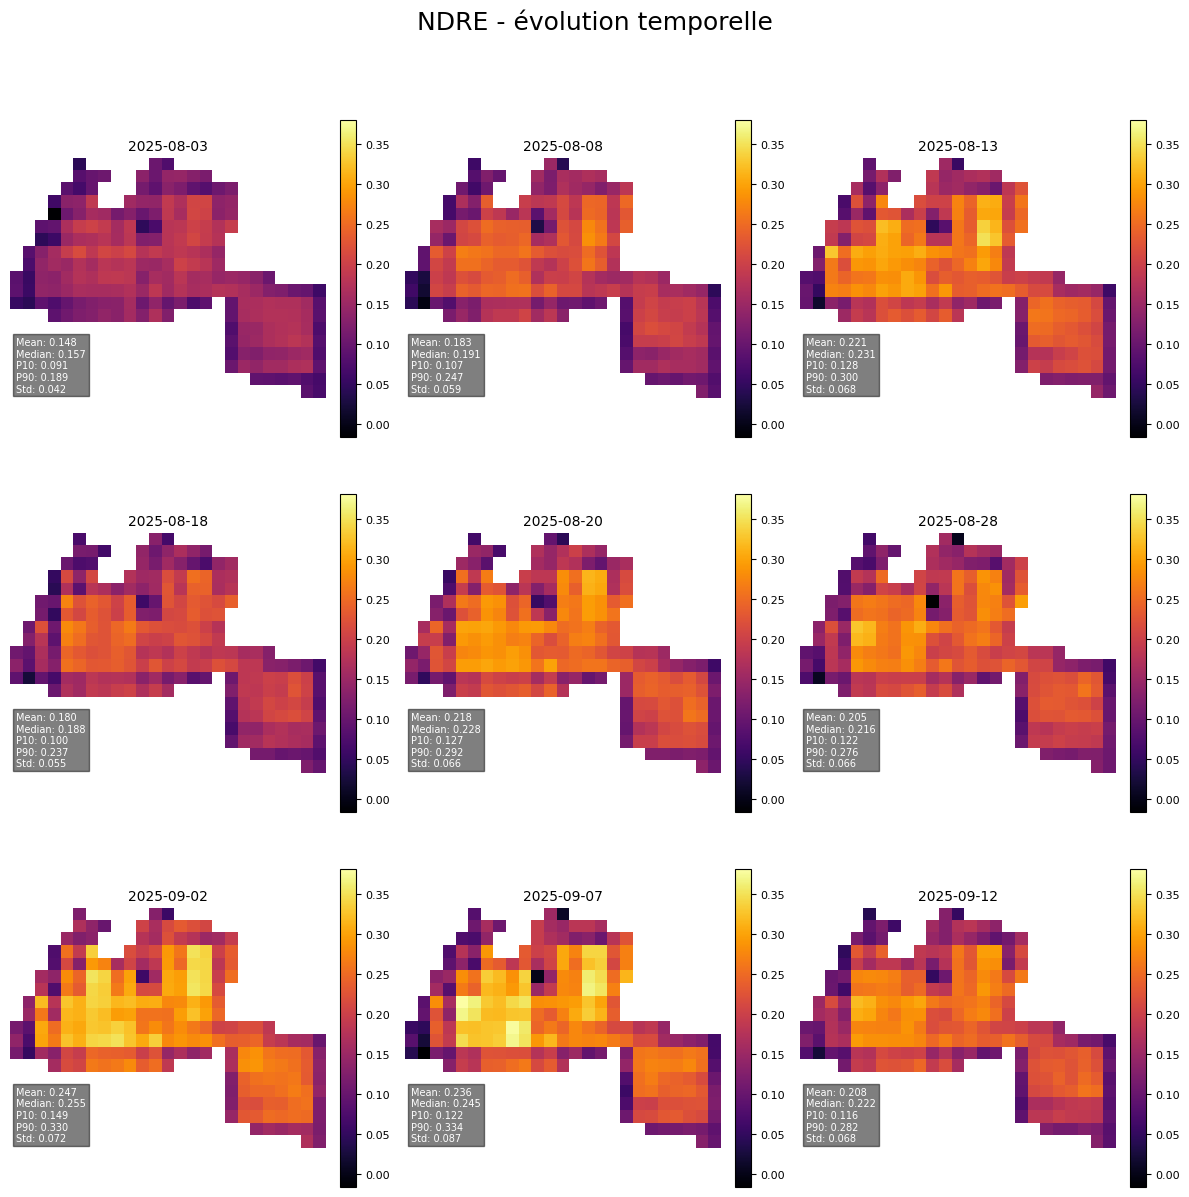

✅ NDRE sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/NDRE_all_dates.png


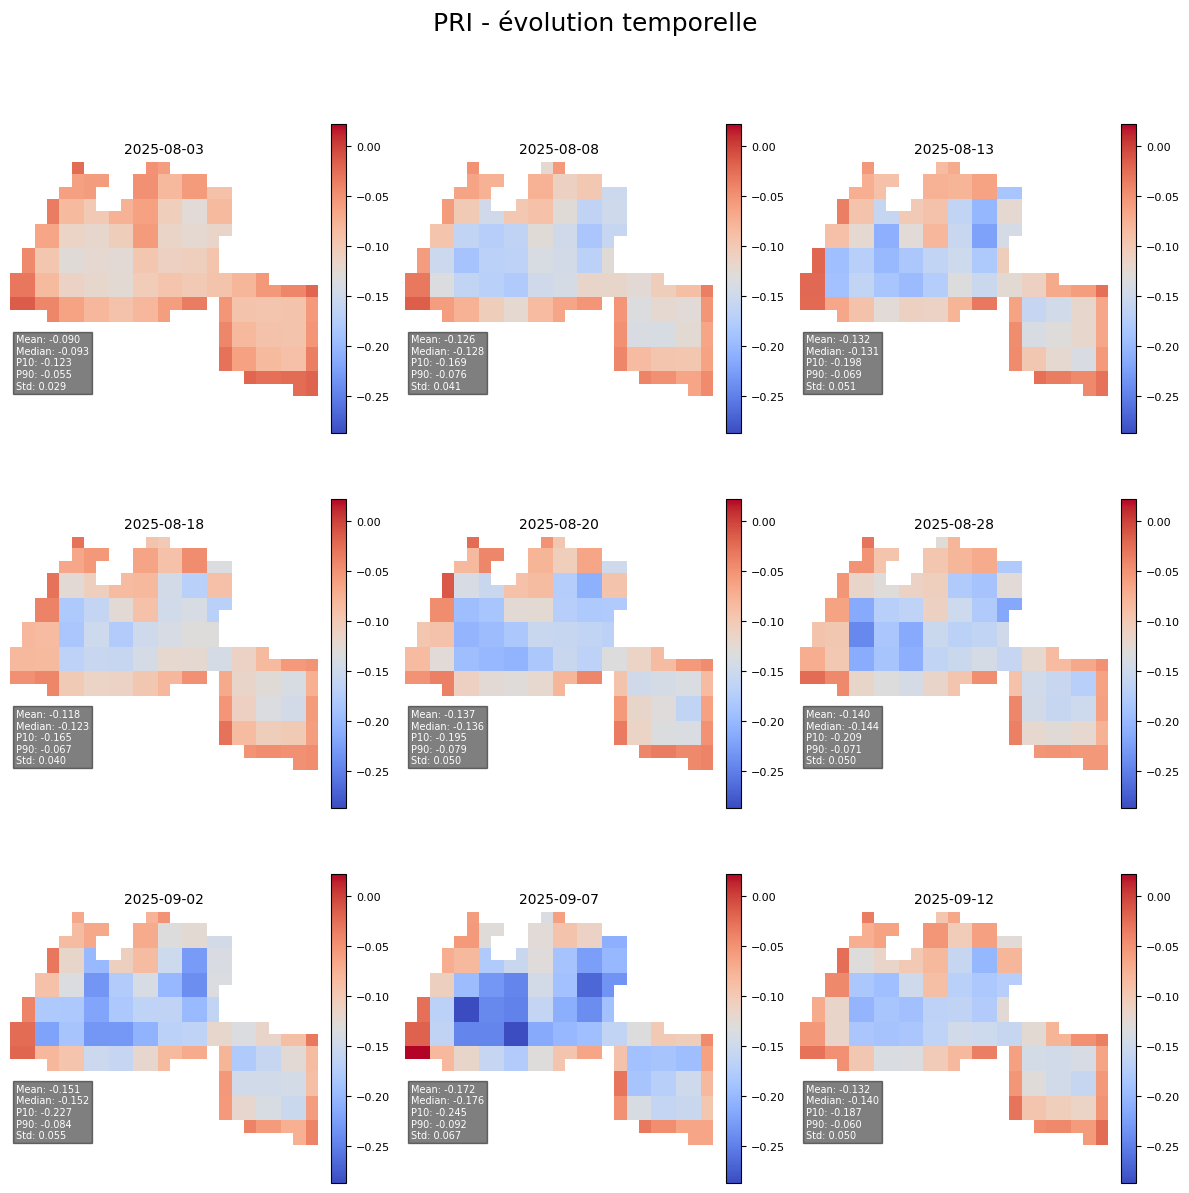

✅ PRI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/PRI_all_dates.png


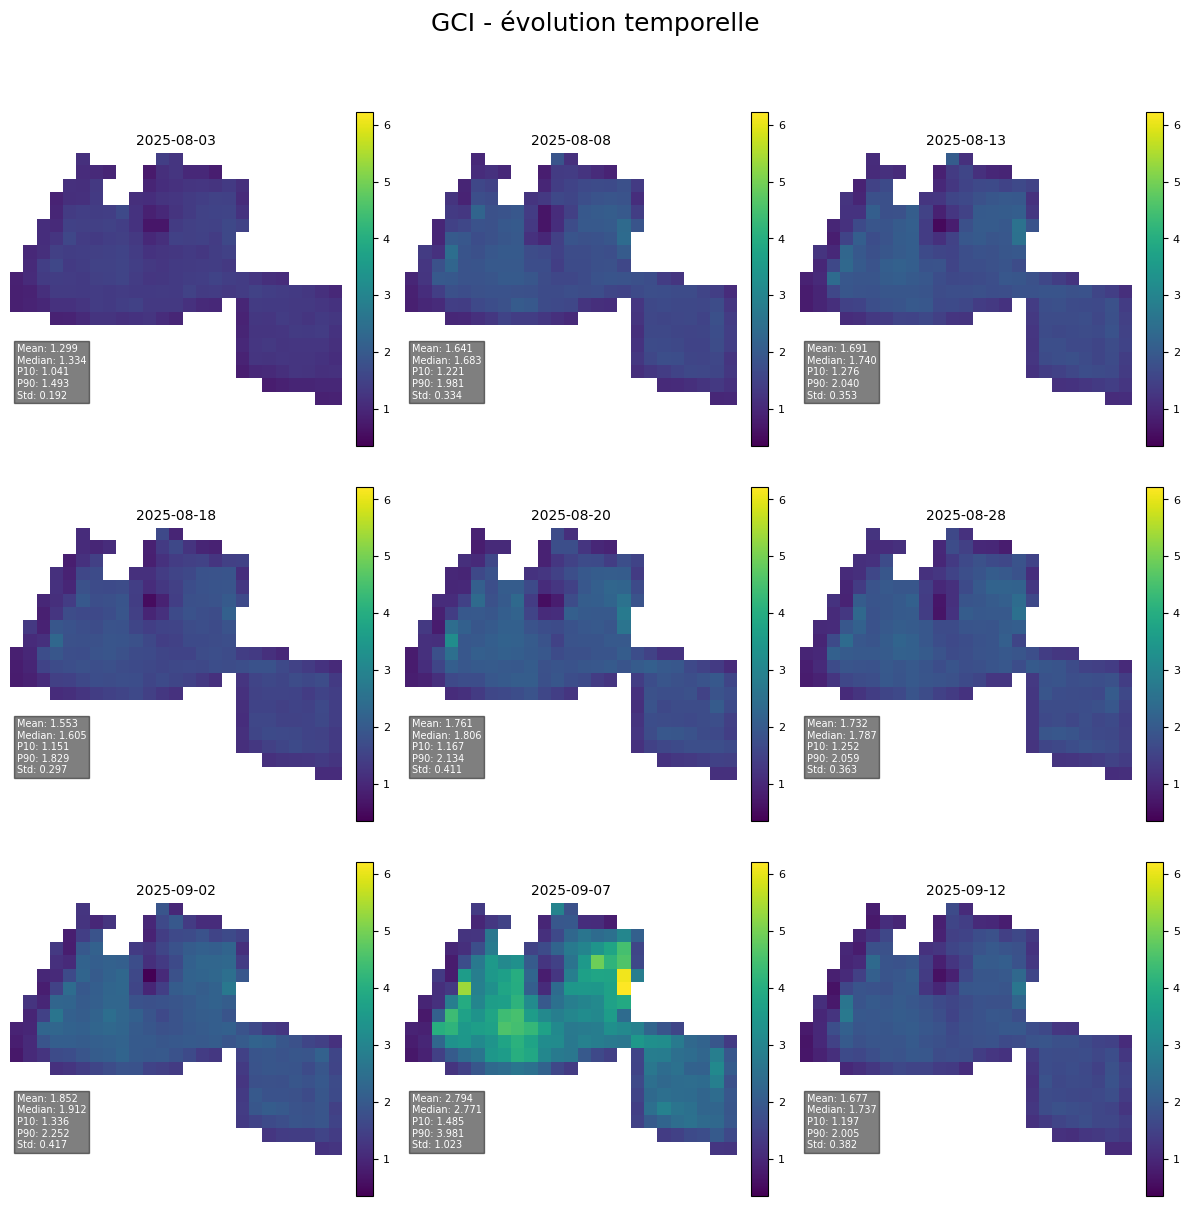

✅ GCI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/GCI_all_dates.png


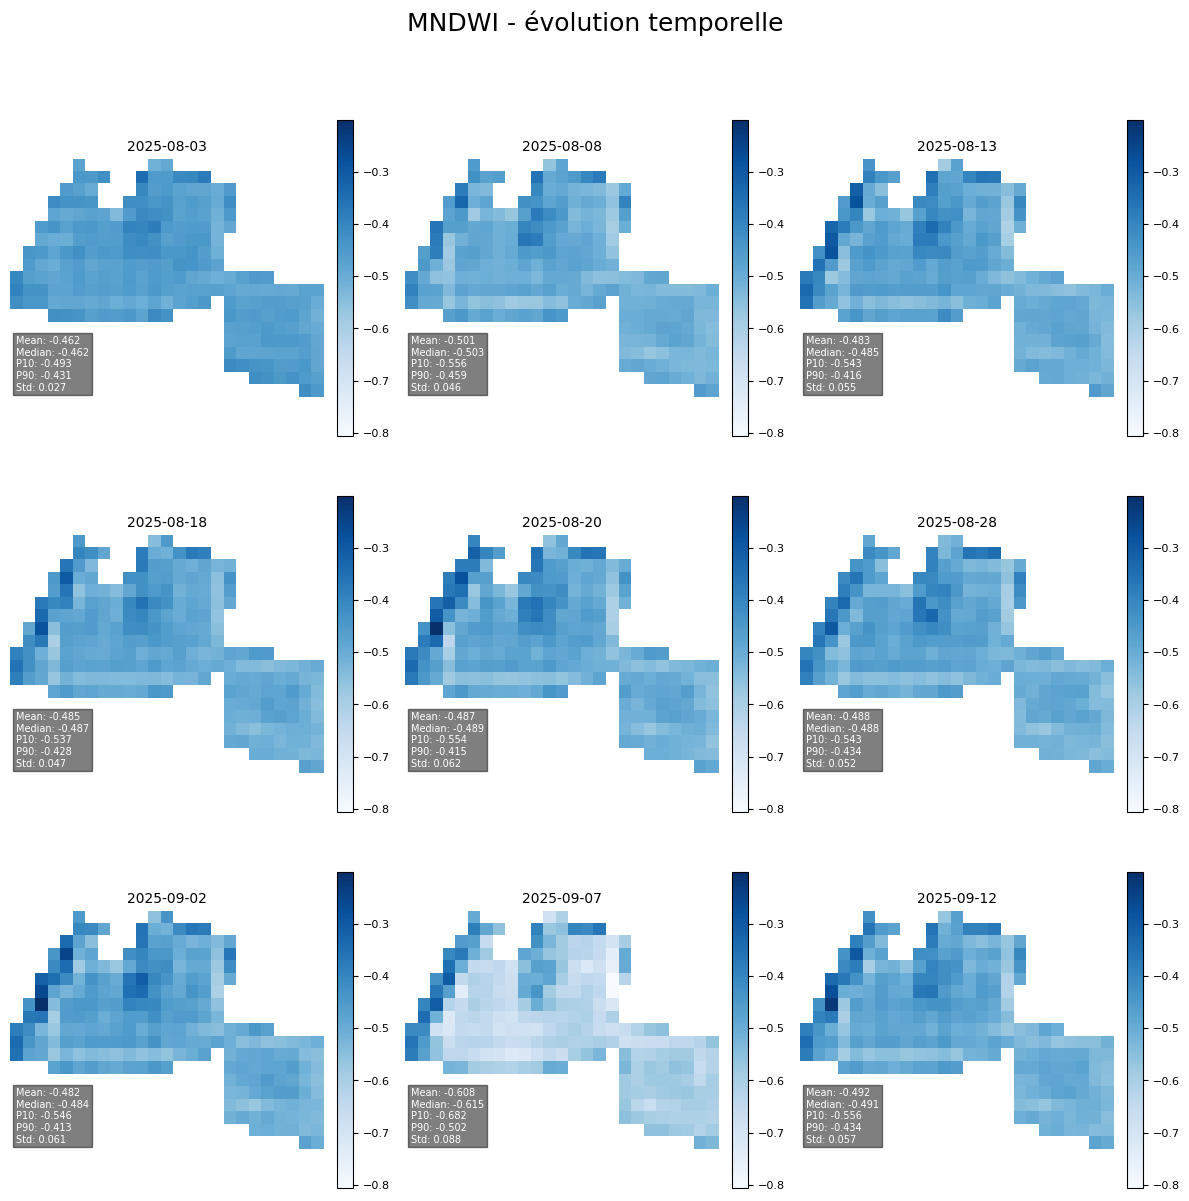

✅ MNDWI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/MNDWI_all_dates.png


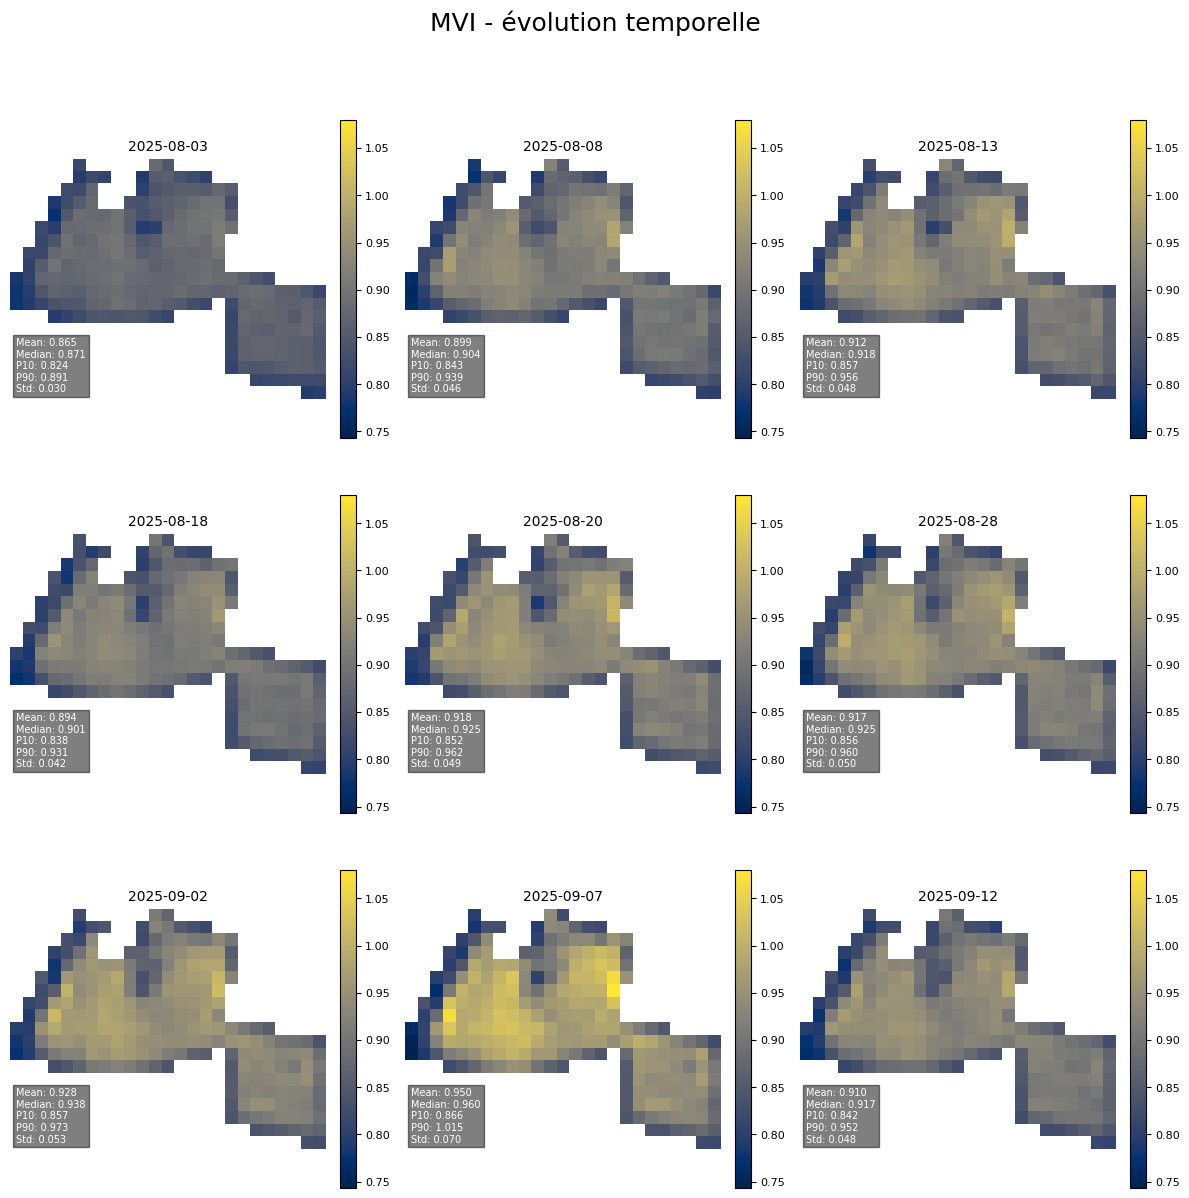

✅ MVI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/MVI_all_dates.png


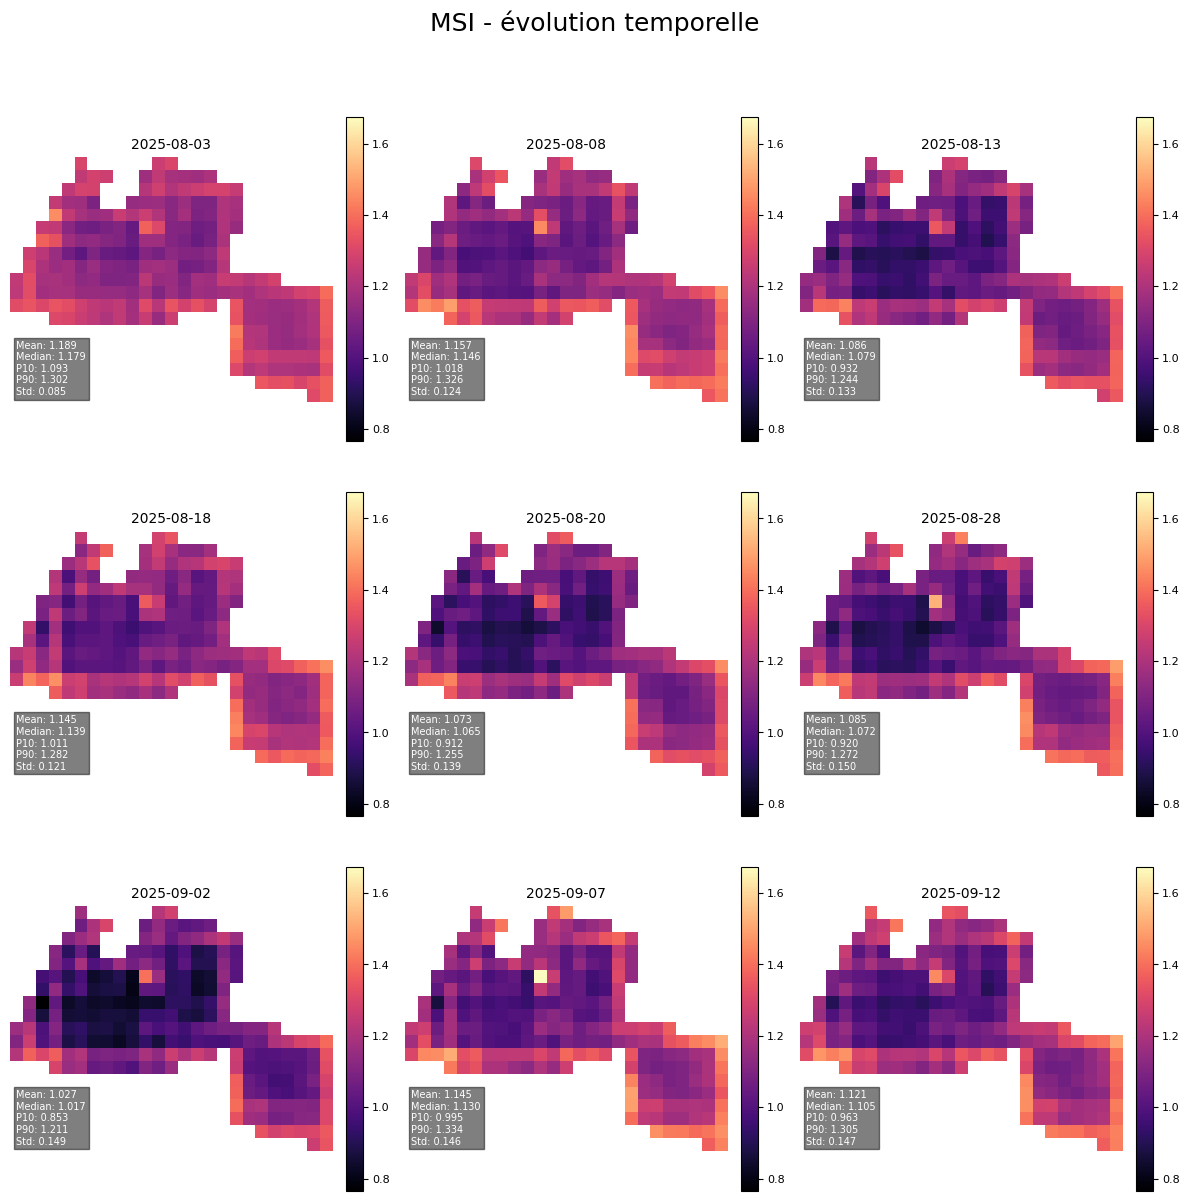

✅ MSI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/MSI_all_dates.png


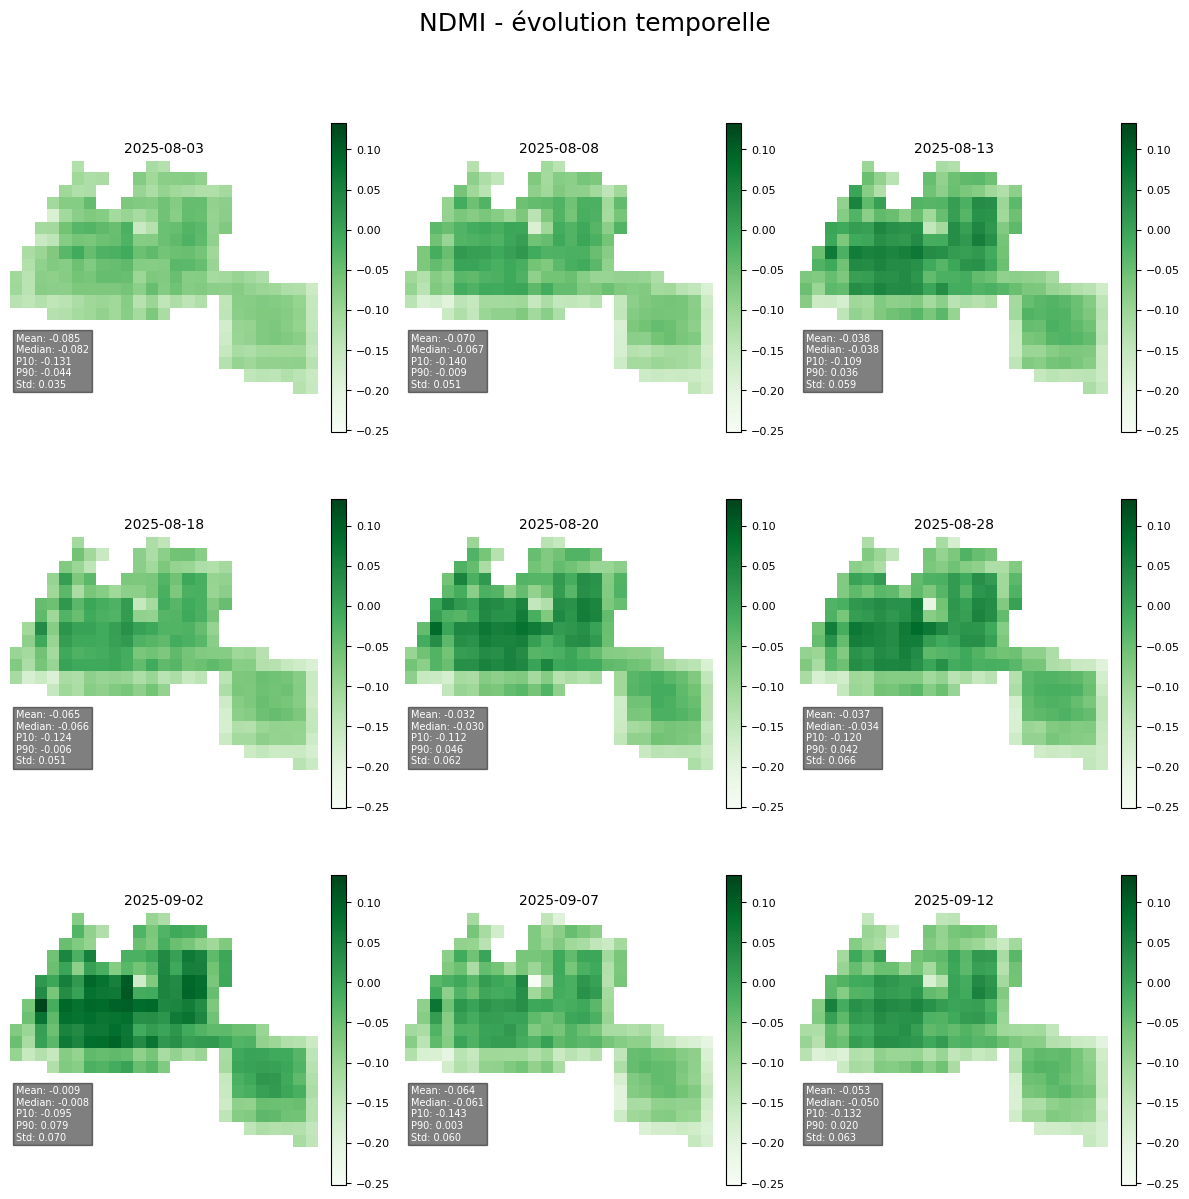

✅ NDMI sauvegardé -> /content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/NDMI_all_dates.png


In [6]:
%pip install rasterio
import os
import math
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

# Charger les stats sauvegardées
df_stats = pd.read_csv("/content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/statistics_summary.csv")

def read_raster(path):
    """Read a raster with rasterio and return array as float + nodata mask applied."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)
    return arr

def get_stats_text(index, date):
    row = df_stats[(df_stats["Index"] == index) & (df_stats["Date"] == date)]
    if row.empty:
        return ""
    r = row.iloc[0]
    return f"Mean: {r['Mean']:.3f}\nMedian: {r['Median']:.3f}\nP10: {r['P10']:.3f}\nP90: {r['P90']:.3f}\nStd: {r['Std']:.3f}"

# 📂 Dossier contenant tes GeoTIFF exportés
dir_path="/content/drive/MyDrive/Agriculture 2.0/test_plots"
ls = [f"{dir_path}/{file}" for file in os.listdir(dir_path) if file.endswith(".tif")]

# 🎨 Palettes
palettes = {
    "NDVI": plt.cm.YlGn,
    "PRI": plt.cm.coolwarm,
    "NDRE": plt.cm.inferno,
    "GCI": plt.cm.viridis,
    "MNDWI": plt.cm.Blues,
    "MVI": plt.cm.cividis,
    "NDMI": plt.cm.Greens,
    "MSI": plt.cm.magma
}

# 🔹 Regrouper les fichiers par index
grouped_files = defaultdict(list)
for f in ls:
    fname = os.path.basename(f)
    ind = fname.split("_")[0]
    grouped_files[ind].append(f)

# 🔹 Boucle par index
for ind, file_list in grouped_files.items():
    n = len(file_list)
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    vmin, vmax = None, None
    arrays = []

    for fpath in sorted(file_list):
        arr = read_raster(fpath)
        arrays.append((os.path.basename(fpath), arr))

        if vmin is None or np.nanmin(arr) < vmin:
            vmin = np.nanmin(arr)
        if vmax is None or np.nanmax(arr) > vmax:
            vmax = np.nanmax(arr)

    cmap = palettes.get(ind, plt.cm.viridis)

    for ax, (fname, arr) in zip(axes, arrays):
        im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
        date_str = fname.replace(f"{ind}_", "").replace(".tif", "")
        ax.set_title(date_str, fontsize=10)
        ax.axis("off")
        cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)

        # 📝 Ajouter stats
        stats_text = get_stats_text(ind, date_str)
        ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
                fontsize=7, color="white", ha="left", va="bottom",
                bbox=dict(facecolor="black", alpha=0.5, pad=2))

    for ax in axes[len(arrays):]:
        ax.axis("off")

    plt.suptitle(f"{ind} - évolution temporelle", fontsize=18, y=1.02)
    plt.tight_layout()
    out_png = f"/content/drive/MyDrive/Agriculture 2.0/Results_heatmaps/{ind}_all_dates.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ {ind} sauvegardé -> {out_png}")
